# 06 — Robustezza rispetto all’inizializzazione casuale

In questo notebook viene verificata la robustezza dei principali risultati rispetto alla casualità introdotta durante il fine-tuning del VAE.

L’esperimento viene ripetuto utilizzando tre seed differenti, 42, 123 e 2026, per tre valori rappresentativi di β: 1e-4, 1e-3 e 1e-2.

Per ciascun modello vengono misurati Rate, D_mu, D_sample, stochasticity gap e deviazione standard media del posterior.

L’obiettivo non è ottenere risultati numericamente identici tra i diversi seed, ma verificare che rimanga stabile la struttura qualitativa osservata negli esperimenti precedenti: nei regimi a Rate più basso ci aspettiamo un maggiore stochasticity gap e una maggiore incertezza del posterior.

Tutti gli esperimenti partono dallo stesso autoencoder deterministico già pre-addestrato. Di conseguenza, questa analisi verifica la robustezza rispetto alla casualità del fine-tuning VAE e non rispetto al riaddestramento completo dell’intera pipeline.

## 1. Librerie e configurazione

In [3]:
from pathlib import Path
import wave as waveio

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchaudio

from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEEDS = [42, 123, 2026]
BETAS = [1e-4, 1e-3, 1e-2]

MC_SAMPLES = 10

SAMPLE_RATE = 8000
N_SAMPLES = 8000
N_FFT = 256
HOP_LENGTH = 64
SPEC_H = 128
SPEC_W = 128

LATENT_DIM = 128
BATCH_SIZE = 64

EPOCHS = 5
LEARNING_RATE = 5e-5
PRESERVE_WEIGHT = 0.5

NOISE_STD = 0.05
PADDING_WEIGHT = 0.10

CHECKPOINT_DIR = Path("checkpoints")
RESULTS_DIR = Path("results")

print("device:", device)
print("seeds:", SEEDS)
print("betas:", BETAS)


device: cpu
seeds: [42, 123, 2026]
betas: [0.0001, 0.001, 0.01]


## 2. Preparazione del dataset FSDD

In [4]:
recordings_dir = Path("audio_data/free-spoken-digit-dataset-1.0.10/recordings")
wav_files = sorted(recordings_dir.glob("*.wav"))

if len(wav_files) == 0:
    raise FileNotFoundError("Dataset FSDD non trovato.")

def parse_name(path):
    digit, speaker, index = path.stem.split("_")
    return int(digit), speaker, int(index)

def load_fixed_audio(path):
    with waveio.open(str(path), "rb") as f:
        sr = f.getframerate()
        channels = f.getnchannels()
        frames = f.readframes(f.getnframes())

    audio = np.frombuffer(frames, dtype=np.int16).astype(np.float32) / 32768.0

    if channels > 1:
        audio = audio.reshape(-1, channels).mean(axis=1)

    waveform = torch.tensor(audio).unsqueeze(0)

    if sr != SAMPLE_RATE:
        waveform = torchaudio.functional.resample(
            waveform, sr, SAMPLE_RATE
        )

    valid_length = min(waveform.shape[1], N_SAMPLES)

    if waveform.shape[1] < N_SAMPLES:
        waveform = F.pad(
            waveform,
            (0, N_SAMPLES - waveform.shape[1])
        )
    else:
        waveform = waveform[:, :N_SAMPLES]

    mask = torch.zeros_like(waveform)
    mask[:, :valid_length] = 1.0

    return waveform, mask, valid_length

train_files = []
test_files = []

for path in wav_files:
    _, _, idx = parse_name(path)
    if idx <= 4:
        test_files.append(path)
    else:
        train_files.append(path)

print("Train:", len(train_files))
print("Test :", len(test_files))


Train: 2700
Test : 300


## 3. Rappresentazione STFT e normalizzazione

In [5]:
window = torch.hann_window(N_FFT)

def stft_complex(x):
    return torch.stft(
        x.squeeze(0),
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=N_FFT,
        window=window,
        return_complex=True
    )

def crop_logmag(logmag):
    logmag = logmag[:SPEC_H, :]

    if logmag.shape[1] < SPEC_W:
        logmag = F.pad(
            logmag,
            (0, SPEC_W - logmag.shape[1])
        )
    else:
        logmag = logmag[:, :SPEC_W]

    return logmag

def frame_weights(valid_length):
    valid_frames = int(np.ceil(valid_length / HOP_LENGTH)) + 1
    valid_frames = min(valid_frames, SPEC_W)

    w = torch.full(
        (1, SPEC_H, SPEC_W),
        PADDING_WEIGHT,
        dtype=torch.float32
    )
    w[:, :, :valid_frames] = 1.0
    return w

sum_x = 0.0
sum_x2 = 0.0
count_values = 0

for path in train_files:
    clean, _, _ = load_fixed_audio(path)

    X = stft_complex(clean)
    logmag = crop_logmag(torch.log1p(X.abs()))

    sum_x += logmag.sum().item()
    sum_x2 += (logmag ** 2).sum().item()
    count_values += logmag.numel()

SPEC_MEAN = sum_x / count_values
variance = sum_x2 / count_values - SPEC_MEAN ** 2
SPEC_STD = max(variance, 1e-8) ** 0.5

print("SPEC_MEAN:", SPEC_MEAN)
print("SPEC_STD :", SPEC_STD)


SPEC_MEAN: 0.04547776059049216
SPEC_STD : 0.16703430628401916


## 4. Costruzione dei dataset spettrali

In [6]:
class SpectrogramDataset(Dataset):
    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        clean, mask, valid_length = load_fixed_audio(self.files[i])

        # rumore dell'input fisso per file, per confrontare i seed di training
        g = torch.Generator().manual_seed(10000 + i)
        noise = torch.randn(clean.shape, generator=g)

        noisy = torch.clamp(
            clean + NOISE_STD * noise * mask,
            -1.0,
            1.0
        )

        clean_stft = stft_complex(clean)
        noisy_stft = stft_complex(noisy)

        clean_logmag = crop_logmag(torch.log1p(clean_stft.abs()))
        noisy_logmag = crop_logmag(torch.log1p(noisy_stft.abs()))

        clean_img = (
            (clean_logmag - SPEC_MEAN) / SPEC_STD
        ).unsqueeze(0)

        noisy_img = (
            (noisy_logmag - SPEC_MEAN) / SPEC_STD
        ).unsqueeze(0)

        weights = frame_weights(valid_length)

        return noisy_img, clean_img, weights

train_dataset = SpectrogramDataset(train_files)
test_dataset = SpectrogramDataset(test_files)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Dataset pronto")


Dataset pronto


## 5. Autoencoder di riferimento e architettura VAE

In [7]:
class STFTAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU()
        )

        self.fc_encode = nn.Linear(128 * 16 * 16, LATENT_DIM)
        self.fc_decode = nn.Linear(LATENT_DIM, 128 * 16 * 16)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1)
        )

    def encode(self, x):
        return self.fc_encode(self.encoder(x).flatten(1))

    def decode(self, z):
        h = self.fc_decode(z).view(-1, 128, 16, 16)
        return self.decoder(h)

    def forward(self, x):
        return self.decode(self.encode(x))


class STFTVAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU()
        )

        self.fc_mu = nn.Linear(128 * 16 * 16, LATENT_DIM)
        self.fc_logvar = nn.Linear(128 * 16 * 16, LATENT_DIM)
        self.fc_decode = nn.Linear(LATENT_DIM, 128 * 16 * 16)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1)
        )

    def encode(self, x):
        h = self.encoder(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        sigma = torch.exp(0.5 * logvar)
        eps = torch.randn_like(sigma)
        return mu + sigma * eps

    def decode(self, z):
        h = self.fc_decode(z).view(-1, 128, 16, 16)
        return self.decoder(h)


checkpoint = CHECKPOINT_DIR / "stft_autoencoder.pt"

if not checkpoint.exists():
    raise FileNotFoundError("Non trovo checkpoints/stft_autoencoder.pt")

ae_state = torch.load(
    checkpoint,
    map_location=device
)

teacher = STFTAutoencoder().to(device)
teacher.load_state_dict(ae_state)
teacher.eval()

for p in teacher.parameters():
    p.requires_grad = False

print("Teacher Step 6 caricato")


Teacher Step 6 caricato


## 6. Funzione obiettivo e inizializzazione dei modelli

In [8]:
def weighted_mse(recon, target, weights):
    error = (recon - target) ** 2

    numerator = (
        error * weights
    ).sum(dim=(1, 2, 3))

    denominator = (
        weights.sum(dim=(1, 2, 3))
        .clamp_min(1.0)
    )

    return numerator / denominator

def kl_per_example(mu, logvar):
    return -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp(),
        dim=1
    )

def fresh_vae(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = STFTVAE().to(device)
    vae_state = model.state_dict()

    for key, value in ae_state.items():
        if key.startswith("encoder."):
            vae_state[key] = value

    vae_state["fc_mu.weight"] = ae_state["fc_encode.weight"]
    vae_state["fc_mu.bias"] = ae_state["fc_encode.bias"]

    vae_state["fc_decode.weight"] = ae_state["fc_decode.weight"]
    vae_state["fc_decode.bias"] = ae_state["fc_decode.bias"]

    for key, value in ae_state.items():
        if key.startswith("decoder."):
            vae_state[key] = value

    model.load_state_dict(vae_state)

    with torch.no_grad():
        model.fc_logvar.weight.zero_()
        model.fc_logvar.bias.fill_(-6.0)

    return model


## 7. Fine-tuning e valutazione per ciascun seed

In [9]:
def train_and_evaluate(beta_target, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = fresh_vae(seed)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    loader_generator = torch.Generator().manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=loader_generator
    )

    for epoch in range(1, EPOCHS + 1):
        model.train()

        progress = (epoch - 1) / (EPOCHS - 1)
        tau = progress
        beta_eff = beta_target * progress

        for noisy_img, clean_img, weights in train_loader:
            noisy_img = noisy_img.to(device)
            clean_img = clean_img.to(device)
            weights = weights.to(device)

            optimizer.zero_grad()

            with torch.no_grad():
                teacher_recon = teacher(noisy_img)

            mu, logvar = model.encode(noisy_img)

            sigma = torch.exp(0.5 * logvar)
            eps = torch.randn_like(sigma)
            z = mu + tau * sigma * eps

            recon = model.decode(z)
            recon_mu = model.decode(mu)

            D = weighted_mse(
                recon,
                clean_img,
                weights
            )

            P = weighted_mse(
                recon_mu,
                teacher_recon,
                weights
            )

            R = kl_per_example(
                mu,
                logvar
            )

            loss = (
                D.mean()
                + PRESERVE_WEIGHT * P.mean()
                + beta_eff * R.mean()
            )

            loss.backward()
            optimizer.step()

    # valutazione finale
    model.eval()

    total_D_mu = 0.0
    total_D_sample = 0.0
    total_R = 0.0
    total_sigma = 0.0
    count = 0

    torch.manual_seed(seed + 9999)

    with torch.no_grad():
        for noisy_img, clean_img, weights in test_loader:
            noisy_img = noisy_img.to(device)
            clean_img = clean_img.to(device)
            weights = weights.to(device)

            mu, logvar = model.encode(noisy_img)
            sigma = torch.exp(0.5 * logvar)

            recon_mu = model.decode(mu)

            D_mu = weighted_mse(
                recon_mu,
                clean_img,
                weights
            )

            D_sample_sum = torch.zeros_like(D_mu)

            for _ in range(MC_SAMPLES):
                z = model.reparameterize(mu, logvar)
                recon_sample = model.decode(z)

                D_sample_sum += weighted_mse(
                    recon_sample,
                    clean_img,
                    weights
                )

            D_sample = D_sample_sum / MC_SAMPLES

            R = kl_per_example(mu, logvar)

            batch = noisy_img.size(0)

            total_D_mu += D_mu.sum().item()
            total_D_sample += D_sample.sum().item()
            total_R += R.sum().item()
            total_sigma += sigma.mean(dim=1).sum().item()
            count += batch

    D_mu = total_D_mu / count
    D_sample = total_D_sample / count
    Rate = total_R / count
    MeanSigma = total_sigma / count

    return {
        "Rate": Rate,
        "D_mu": D_mu,
        "D_sample": D_sample,
        "Gap": D_sample - D_mu,
        "MeanSigma": MeanSigma
    }


## 8. Esecuzione dei nove esperimenti

In [10]:
rows = []

for beta in BETAS:
    for seed in SEEDS:
        print(
            f"Training beta={beta:.0e}, seed={seed}"
        )

        result = train_and_evaluate(
            beta,
            seed
        )

        rows.append(
            {
                "beta": beta,
                "seed": seed,
                **result
            }
        )

        print(
            f'  R={result["Rate"]:.2f} | '
            f'D_mu={result["D_mu"]:.5f} | '
            f'D_sample={result["D_sample"]:.5f} | '
            f'Gap={result["Gap"]:.5f} | '
            f'sigma={result["MeanSigma"]:.4f}'
        )

        print()

seed_df = pd.DataFrame(rows)

seed_df


Training beta=1e-04, seed=42
  R=338.12 | D_mu=0.24943 | D_sample=0.25376 | Gap=0.00434 | sigma=0.2286

Training beta=1e-04, seed=123
  R=340.73 | D_mu=0.25004 | D_sample=0.25380 | Gap=0.00376 | sigma=0.2267

Training beta=1e-04, seed=2026
  R=339.38 | D_mu=0.25049 | D_sample=0.25415 | Gap=0.00366 | sigma=0.2237

Training beta=1e-03, seed=42
  R=122.49 | D_mu=0.25914 | D_sample=0.29898 | Gap=0.03984 | sigma=0.4654

Training beta=1e-03, seed=123
  R=118.14 | D_mu=0.26131 | D_sample=0.30169 | Gap=0.04038 | sigma=0.4792

Training beta=1e-03, seed=2026
  R=117.81 | D_mu=0.26230 | D_sample=0.30193 | Gap=0.03963 | sigma=0.4810

Training beta=1e-02, seed=42
  R=33.74 | D_mu=0.32201 | D_sample=0.49339 | Gap=0.17139 | sigma=0.7710

Training beta=1e-02, seed=123
  R=32.80 | D_mu=0.32905 | D_sample=0.49115 | Gap=0.16210 | sigma=0.7882

Training beta=1e-02, seed=2026
  R=30.54 | D_mu=0.34030 | D_sample=0.50843 | Gap=0.16812 | sigma=0.8153



,beta,seed,Rate,D_mu,D_sample,Gap,MeanSigma
0,0.0001,42,338.115977,0.249429,0.253765,0.004335,0.228585
1,0.0001,123,340.727106,0.250042,0.253805,0.003762,0.226719
2,0.0001,2026,339.380957,0.250489,0.254153,0.003665,0.223702
3,0.0010,42,122.492573,0.259144,0.298982,0.039838,0.465426
4,0.0010,123,118.137834,0.261315,0.301693,0.040378,0.479237
5,0.0010,2026,117.811556,0.262299,0.301934,0.039635,0.481022
6,0.0100,42,33.735151,0.322007,0.493394,0.171387,0.771047
7,0.0100,123,32.799652,0.329054,0.491153,0.162099,0.788199
8,0.0100,2026,30.538710,0.340301,0.508426,0.168125,0.815304


## 9. Analisi di media e deviazione standard

In [11]:
summary_df = (
    seed_df
    .groupby("beta")
    .agg(
        Rate_mean=("Rate", "mean"),
        Rate_std=("Rate", "std"),
        D_mu_mean=("D_mu", "mean"),
        D_mu_std=("D_mu", "std"),
        D_sample_mean=("D_sample", "mean"),
        D_sample_std=("D_sample", "std"),
        Gap_mean=("Gap", "mean"),
        Gap_std=("Gap", "std"),
        Sigma_mean=("MeanSigma", "mean"),
        Sigma_std=("MeanSigma", "std")
    )
    .reset_index()
)

summary_df


,beta,Rate_mean,Rate_std,D_mu_mean,D_mu_std,D_sample_mean,D_sample_std,Gap_mean,Gap_std,Sigma_mean,Sigma_std
0,0.0001,339.408013,1.305775,0.249987,0.000532,0.253908,0.000214,0.003921,0.000362,0.226335,0.002464
1,0.0010,119.480654,2.613495,0.260919,0.001614,0.300870,0.001639,0.039950,0.000384,0.475228,0.008536
2,0.0100,32.357837,1.643383,0.330454,0.009227,0.497658,0.009392,0.167204,0.004712,0.791517,0.022314


## 10. Robustezza della curva Rate–Distortion

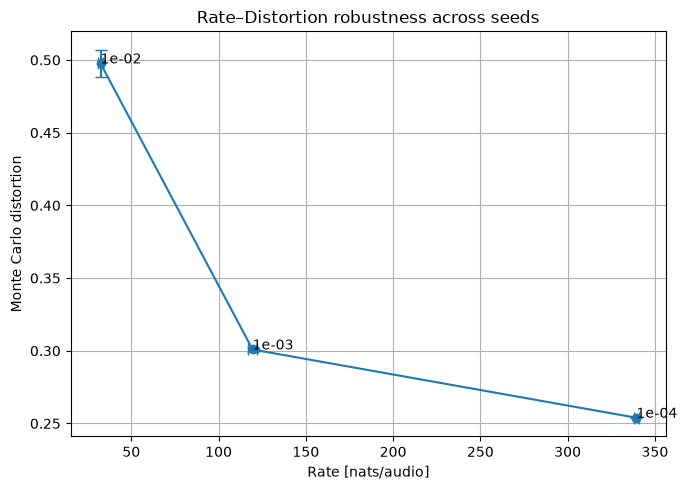

In [12]:
plt.figure(figsize=(7, 5))

plt.errorbar(
    summary_df["Rate_mean"],
    summary_df["D_sample_mean"],
    xerr=summary_df["Rate_std"],
    yerr=summary_df["D_sample_std"],
    marker="o",
    capsize=4
)

for _, row in summary_df.iterrows():
    plt.annotate(
        f'{row["beta"]:.0e}',
        (
            row["Rate_mean"],
            row["D_sample_mean"]
        )
    )

plt.xlabel("Rate [nats/audio]")
plt.ylabel("Monte Carlo distortion")
plt.title("Rate–Distortion robustness across seeds")
plt.grid(True)
plt.tight_layout()
plt.show()


## 11. Robustezza dello stochasticity gap

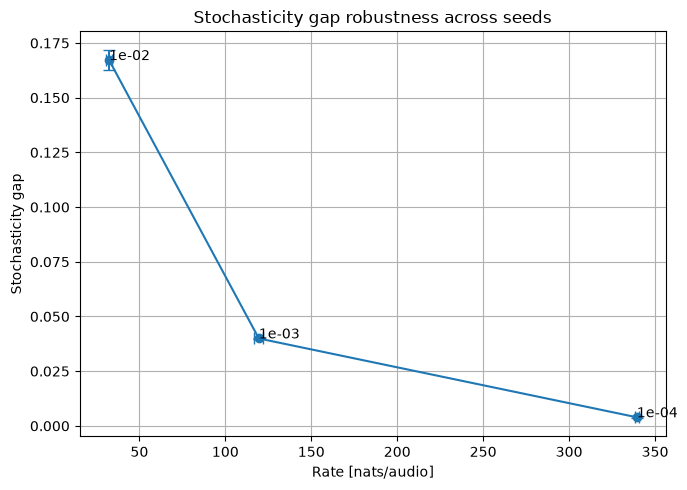

In [13]:
plt.figure(figsize=(7, 5))

plt.errorbar(
    summary_df["Rate_mean"],
    summary_df["Gap_mean"],
    xerr=summary_df["Rate_std"],
    yerr=summary_df["Gap_std"],
    marker="o",
    capsize=4
)

for _, row in summary_df.iterrows():
    plt.annotate(
        f'{row["beta"]:.0e}',
        (
            row["Rate_mean"],
            row["Gap_mean"]
        )
    )

plt.xlabel("Rate [nats/audio]")
plt.ylabel("Stochasticity gap")
plt.title("Stochasticity gap robustness across seeds")
plt.grid(True)
plt.tight_layout()
plt.show()


## 12. Relazione tra incertezza del posterior e stochasticity gap

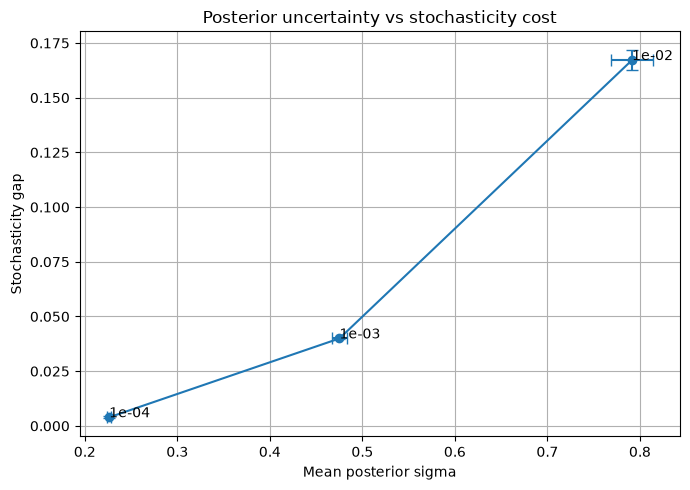

In [14]:
plt.figure(figsize=(7, 5))

plt.errorbar(
    summary_df["Sigma_mean"],
    summary_df["Gap_mean"],
    xerr=summary_df["Sigma_std"],
    yerr=summary_df["Gap_std"],
    marker="o",
    capsize=4
)

for _, row in summary_df.iterrows():
    plt.annotate(
        f'{row["beta"]:.0e}',
        (
            row["Sigma_mean"],
            row["Gap_mean"]
        )
    )

plt.xlabel("Mean posterior sigma")
plt.ylabel("Stochasticity gap")
plt.title("Posterior uncertainty vs stochasticity cost")
plt.grid(True)
plt.tight_layout()
plt.show()


## 13. Salvataggio dei risultati

In [15]:
seed_df.to_csv(
    RESULTS_DIR / "seed_runs.csv",
    index=False
)

summary_df.to_csv(
    RESULTS_DIR / "seed_summary.csv",
    index=False
)

print("Salvato: results/seed_runs.csv")
print("Salvato: results/seed_summary.csv")


Salvato: results/seed_runs.csv
Salvato: results/seed_summary.csv


# Criteri di robustezza

L’obiettivo dell’analisi non è ottenere valori identici per i diversi seed, ma verificare che la struttura qualitativa dei risultati rimanga stabile.

In particolare, consideriamo il risultato robusto se:

- il Rate medio diminuisce passando da β = 1e-4 a β = 1e-2;
- lo stochasticity gap medio aumenta;
- la deviazione standard media del posterior aumenta;
- le deviazioni standard tra seed rimangono abbastanza contenute da non invertire le tendenze principali.

Se queste condizioni sono soddisfatte, possiamo concludere che il risultato principale è stabile rispetto alla casualità introdotta durante il fine-tuning del VAE.

# Interpretazione finale dei risultati

I risultati mostrano che le principali tendenze osservate negli esperimenti precedenti rimangono stabili al variare del seed utilizzato durante il fine-tuning del VAE.

Passando da β = 1e-4 a β = 1e-2, il Rate medio diminuisce nettamente, mentre aumentano sia lo stochasticity gap sia la deviazione standard media del posterior.

Le deviazioni standard tra i diversi seed risultano contenute rispetto alle differenze osservate tra i tre regimi di β e non modificano l’ordinamento delle tendenze principali.

In particolare, i modelli caratterizzati da Rate più basso presentano sistematicamente una maggiore incertezza del posterior e un maggiore costo associato al sampling.

Questi risultati supportano quindi la robustezza della relazione osservata tra Rate, incertezza latente e stochasticity gap rispetto alla casualità del fine-tuning.

La verifica riguarda esclusivamente il fine-tuning del VAE, poiché tutti gli esperimenti utilizzano lo stesso autoencoder deterministico pre-addestrato come inizializzazione.